# Visualization (By Filip Pristaš)
Lastly, I thought it would be interesting to see what the models actually see when they are given an image. So I created this notebook that takes an image, and runs it through each layer separately, and plots the immediate outputs based on what kind of layer it is.

In [1]:
import keras
import cv2
import matplotlib.pyplot as plt
import numpy

from math import sqrt
from keras.src.layers import MaxPooling2D, Conv2D, Flatten, Dense, Dropout


def predict_image_class(image, local_model, verbose):
    prediction = local_model.predict(numpy.array([image]), verbose=verbose)
    predict = prediction.argmax()
    return predict


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,268,762 (12.47 MB)

 Trainable params: 3,268,762 (12.47 MB)

 Non-trainable params: 0 (0.00 B)

None


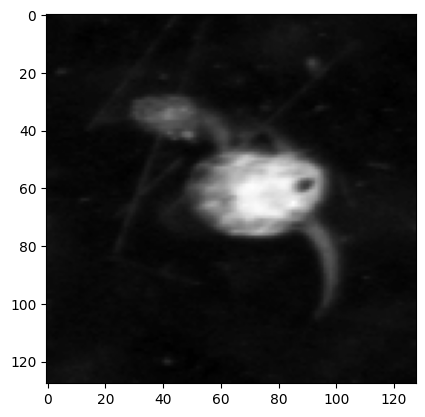

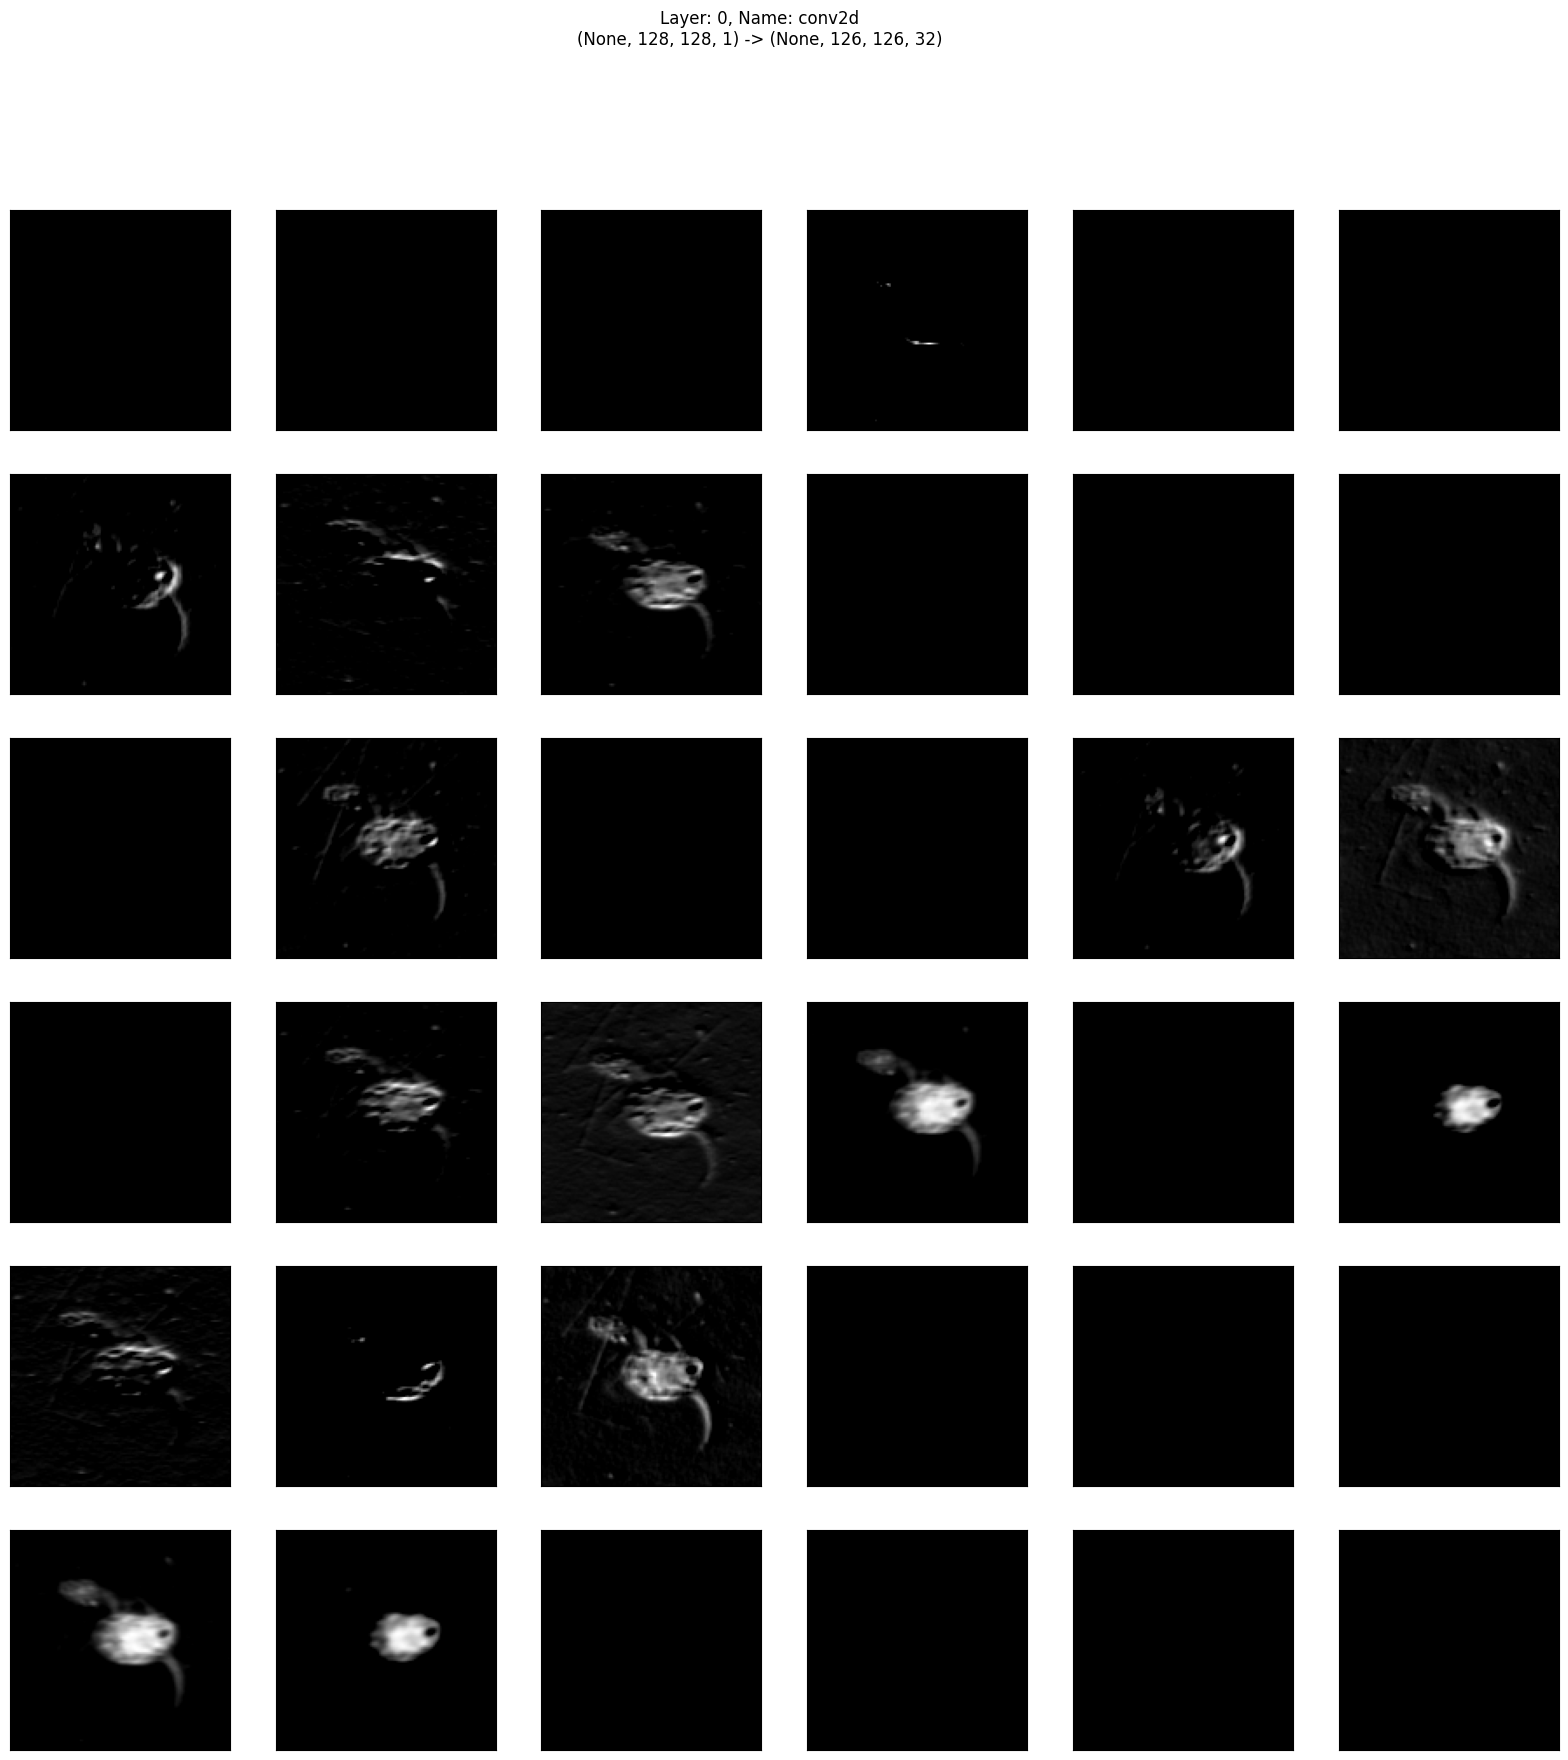

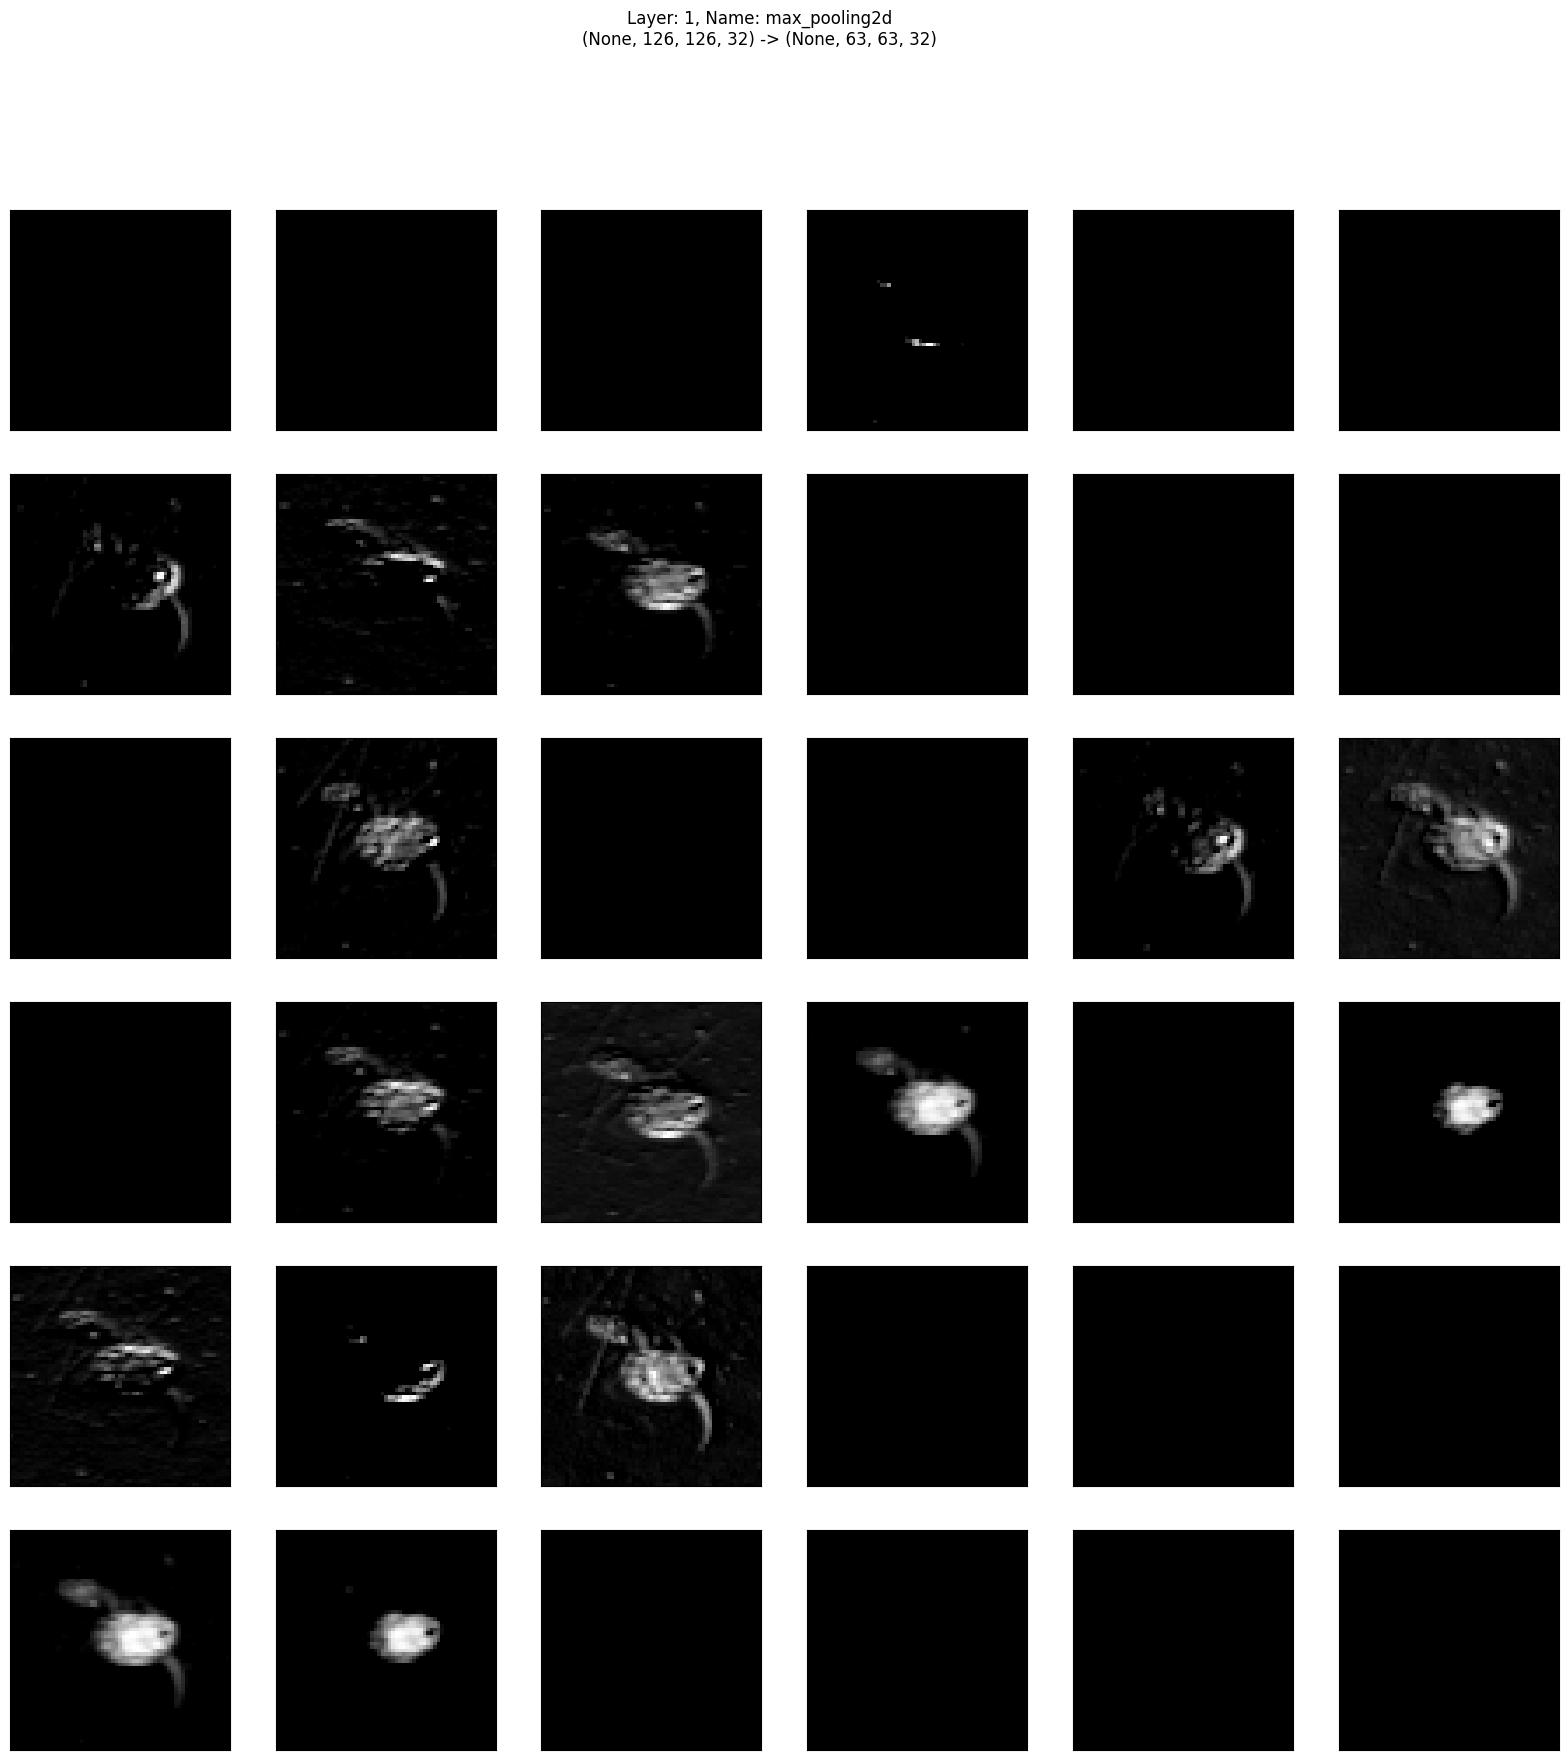

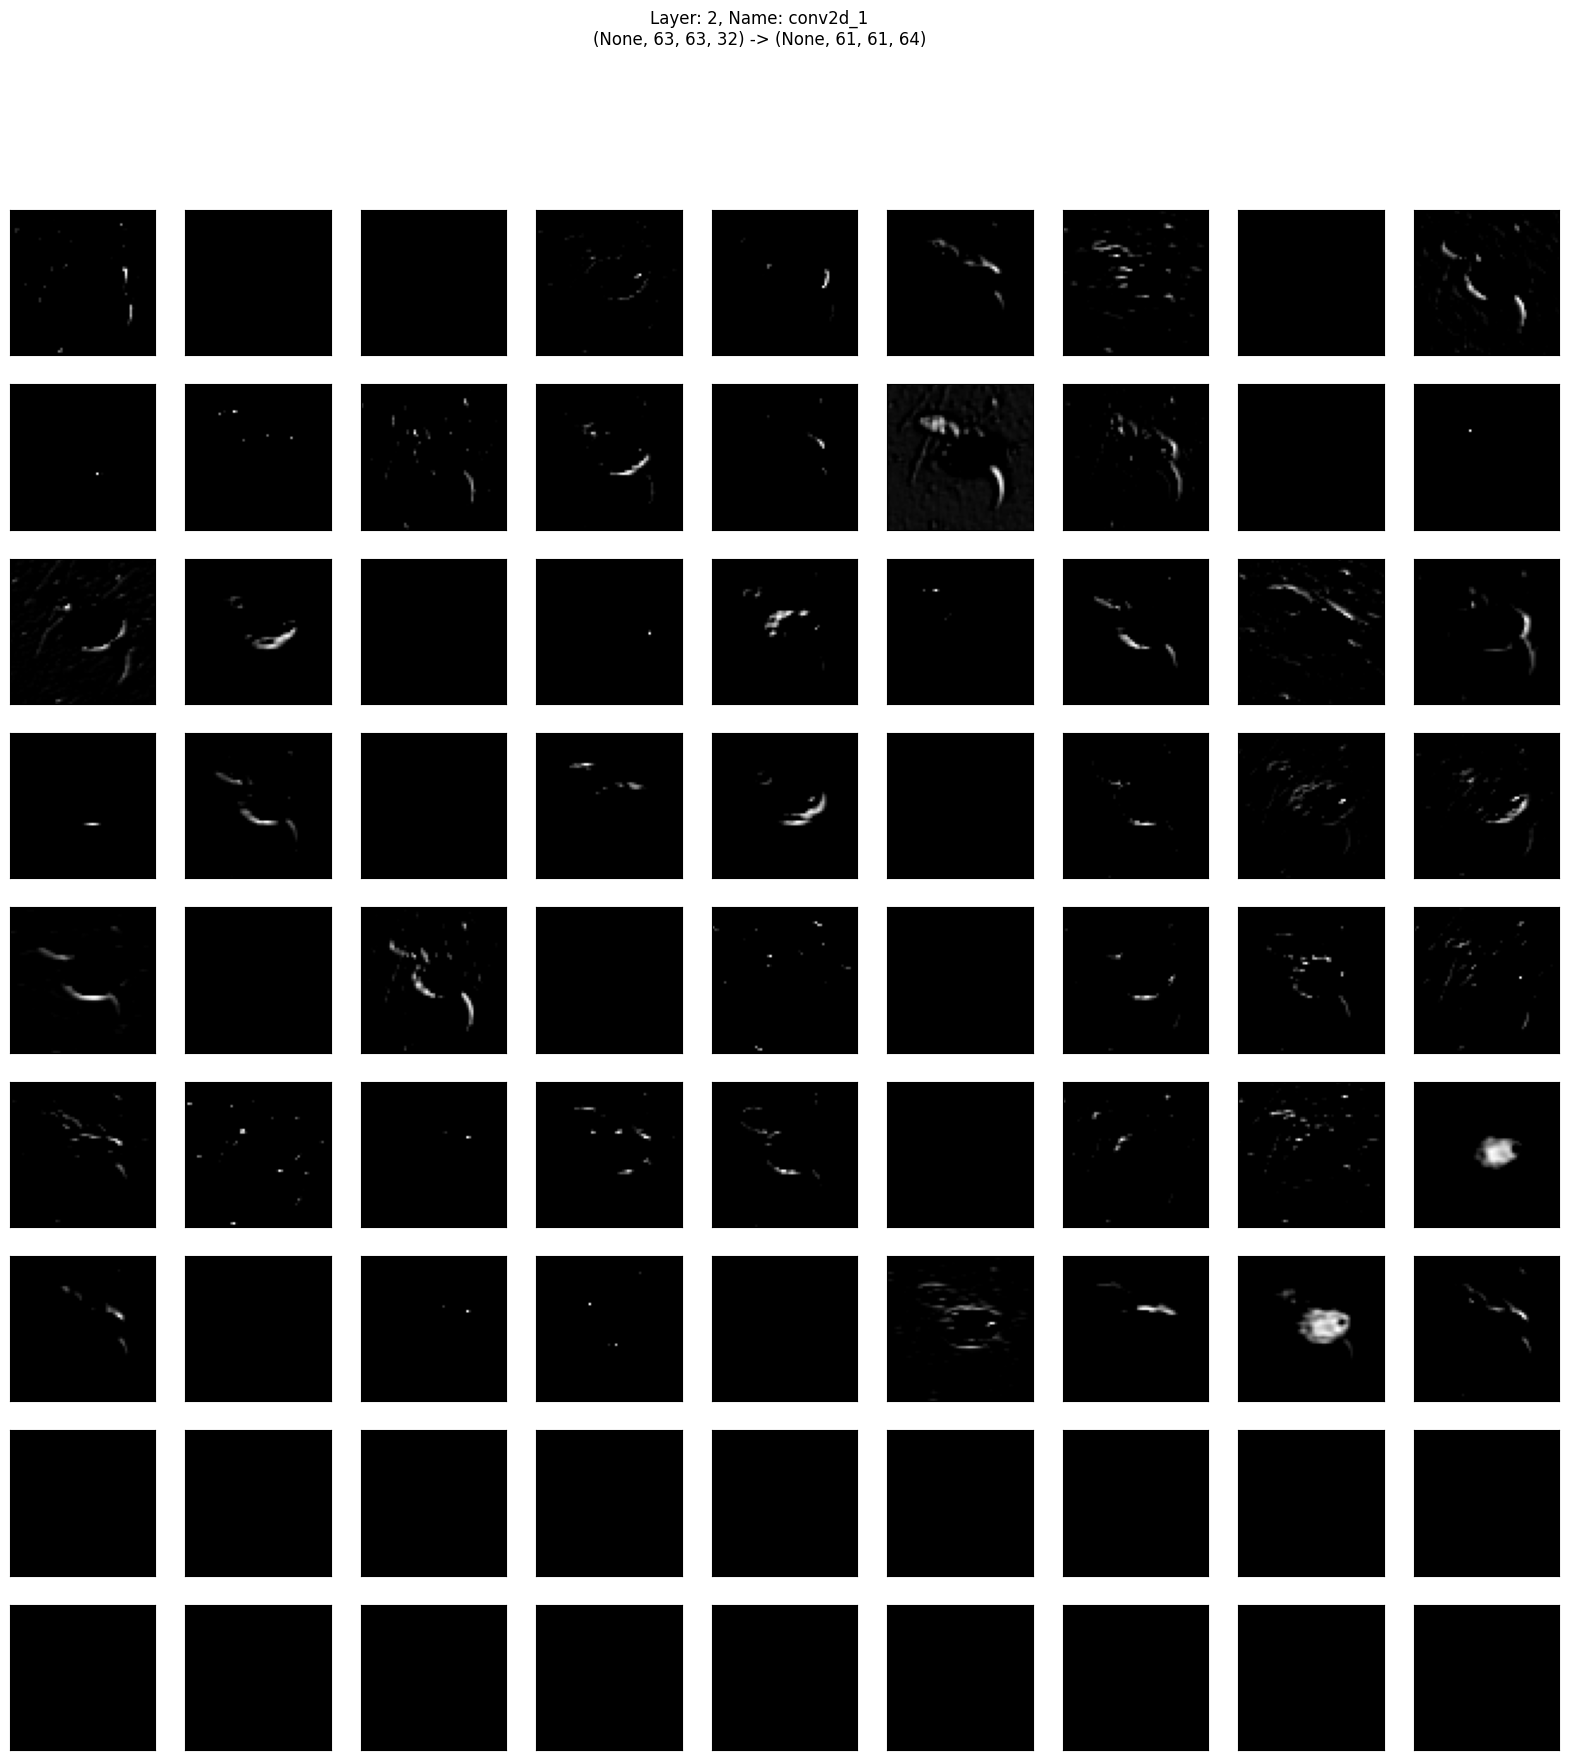

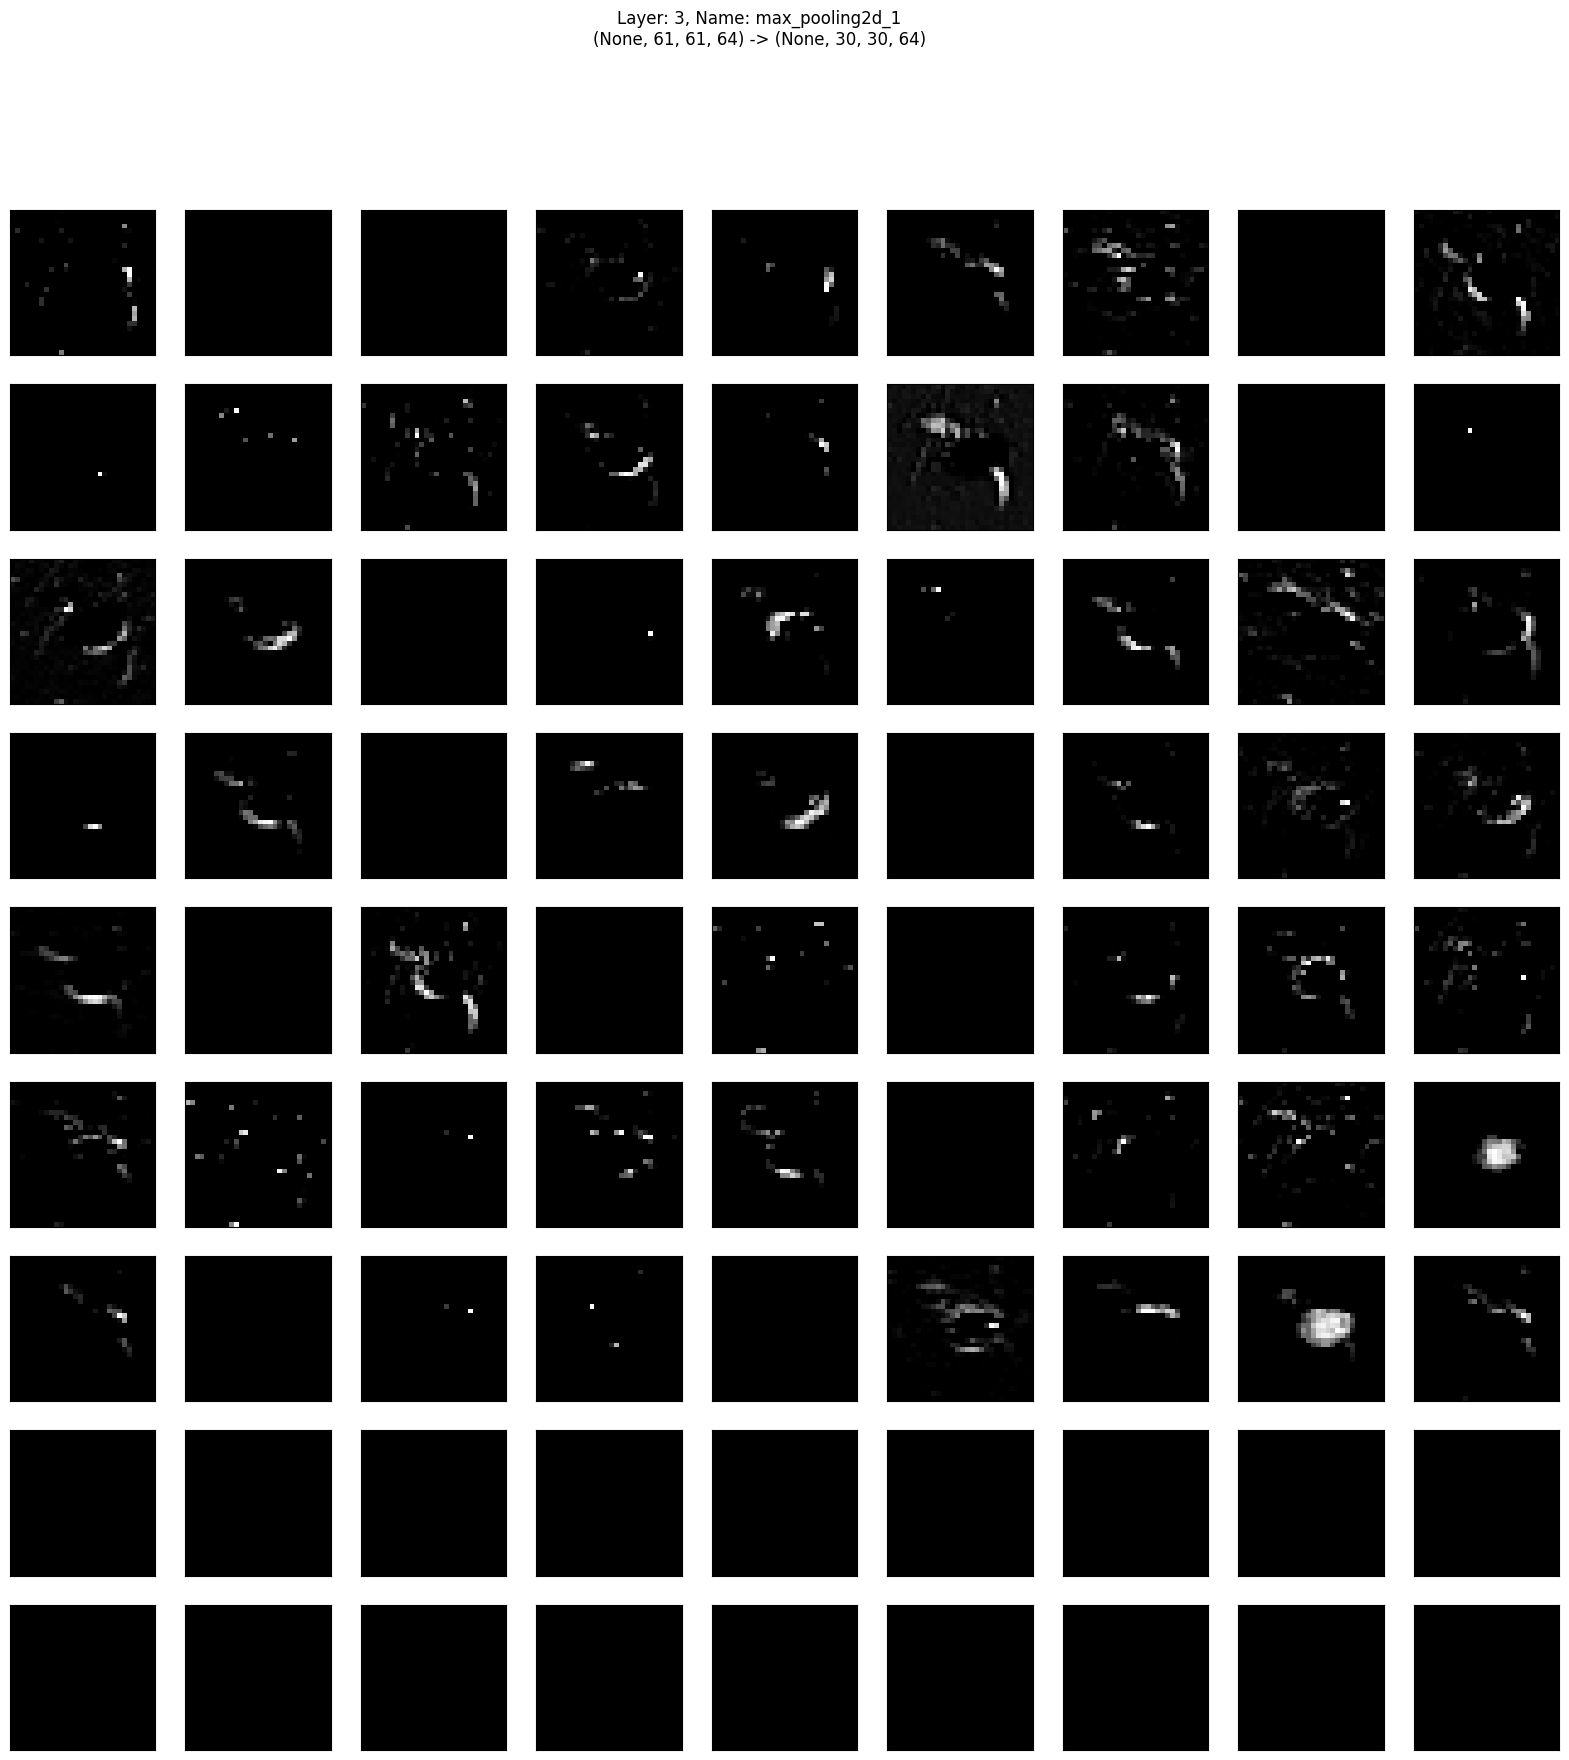

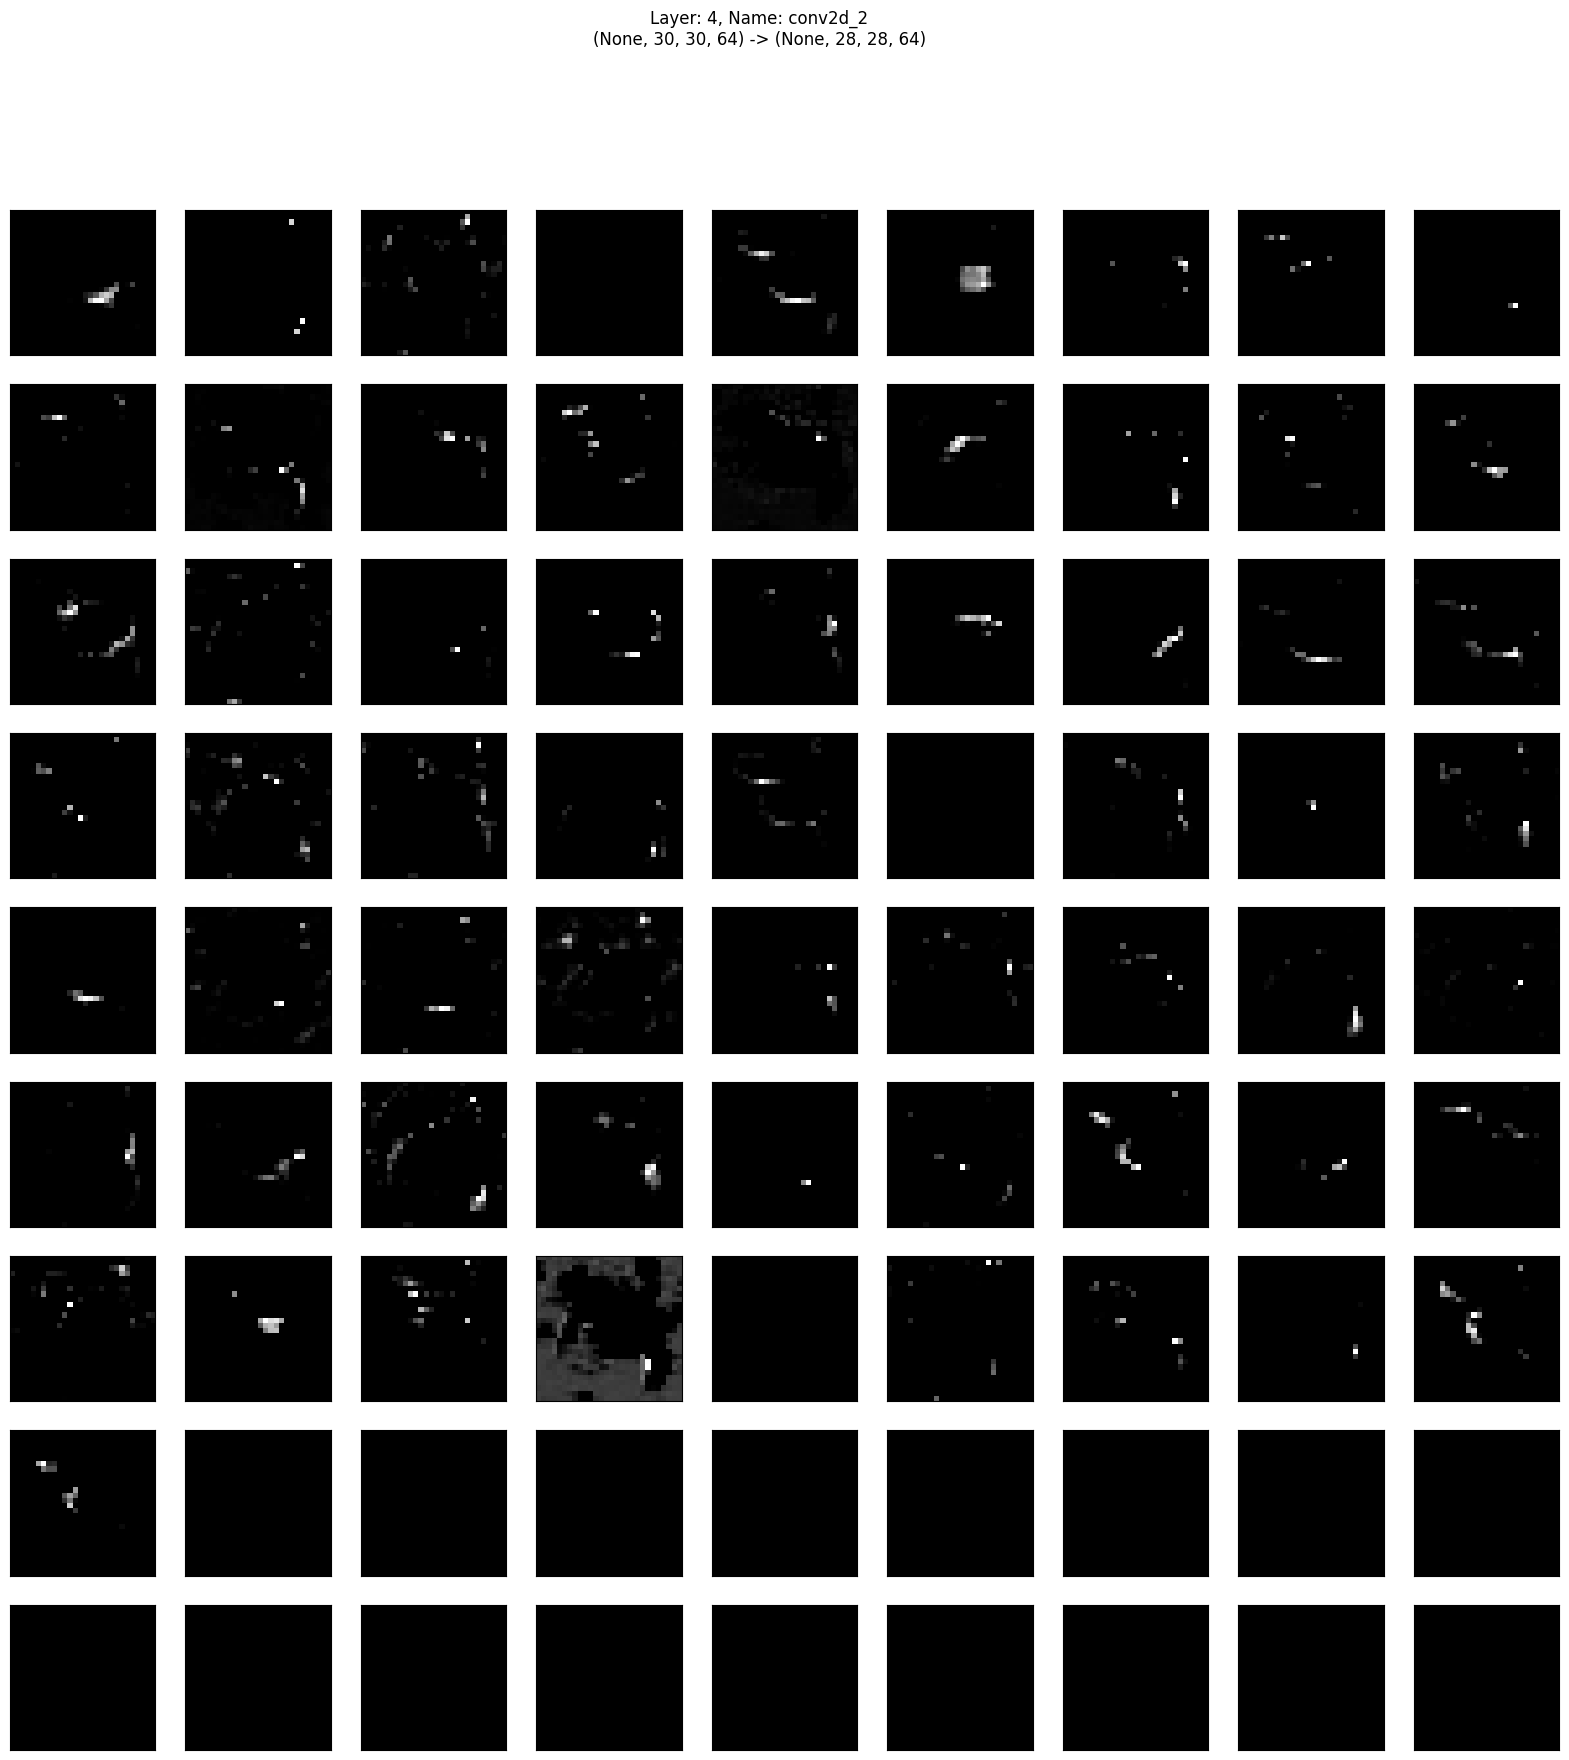

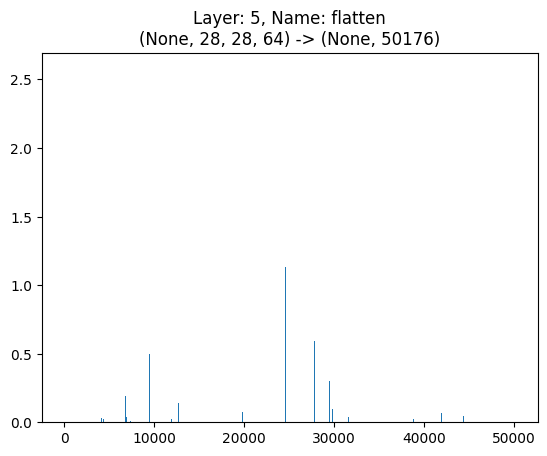

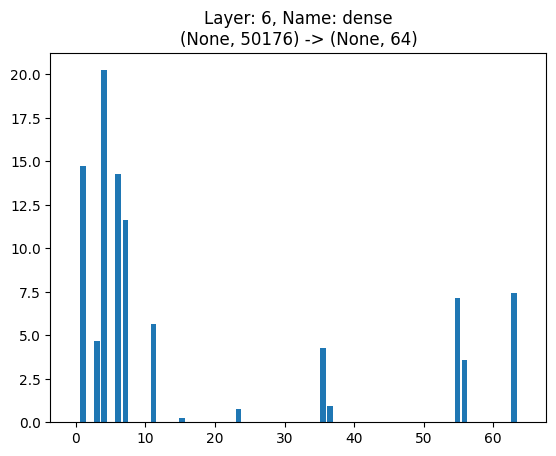

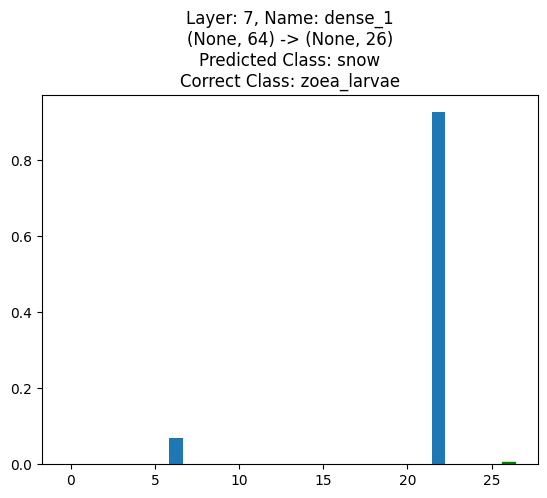

In [13]:

################### Variables Definition ###################
path_to_image = "D:/ML_Dataset/subsets/equal_dist_100/zoea_larvae/training_zoea_larvae_roi0.2751065200.tif.png"
model = keras.models.load_model("models/plankton_cnn_model3.h5")
verbosity = 3
############################################################

number_to_class = ['actinotrocha', 'amphipods', 'appendicularia', 'appendicularia_house', 'bipinnaria', 'blurry', 'copepods', 'diatoms', 'echinodermata', 'eggs', 'larvae', 'malacostraca', 'medusae', 'mnemiopsis', 'noctiluca', 'phaeocystis', 'pilidium', 'pluteus', 'polychaeta', 'pteropods', 'rod', 'snow', 'unknown', 'veliger_larvae', 'worms', 'zoea_larvae']

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

# Read and preprocess the image
img = cv2.imread(path_to_image)
resized = cv2.resize(img, model.input_shape[1:3])
if model.input_shape[3] == 1:
    color = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
elif model.input_shape[3] == 3:
    color = resized # No change
else:
    raise RuntimeError(f"No way of converting an image to {model.input_shape[3]} channels")
resized = color / 255.0
resized = numpy.expand_dims(resized, axis=-1)
plt.imshow(resized, cmap='gray')
plt.show()

selected_image_class = path_to_image.split("/")[-2]
selected_image_class_num = number_to_class.index(selected_image_class)

# This is used in every interation of the loop, as it serves as an output of a layer, and input for the next layer at the same time.
feature_maps = numpy.array([resized])

for i, layer in enumerate(model.layers):
    # If the layer is a Conv2D, MaxPooling, or Dropout, the images get plotted in a figure.
    if isinstance(layer, Conv2D) or isinstance(layer, MaxPooling2D) or isinstance(layer, Dropout):
        sub_model = keras.models.Sequential()
        sub_model.add(layer)
        feature_maps = sub_model.predict(feature_maps, verbose=verbosity)
        fig, axs = plt.subplots(int(sqrt(feature_maps.shape[-1]))+1, int(sqrt(feature_maps.shape[-1]))+1, figsize=(20, 20))
        fig.suptitle(f"Layer: {i}, Name: {layer.name}\n{layer.input.shape} -> {layer.output.shape}")
        for j, ax in enumerate(axs.flat):
            ax.set_xticks([])
            ax.set_yticks([])
            if j >= feature_maps.shape[-1]:
                dummy_image = numpy.zeros((feature_maps.shape[1], feature_maps.shape[2]))
                ax.imshow(dummy_image, cmap='gray')
                continue
            ax.imshow(feature_maps[0, :, :, j], cmap='gray')
        plt.show()

    # If it is a single dimensional layer, then we plot a graph instead
    elif isinstance(layer, Dense) or isinstance(layer, Flatten):
        sub_model = keras.models.Sequential()
        sub_model.add(layer)
        feature_maps = sub_model.predict(feature_maps, verbose=verbosity)
        title = f"Layer: {i}, Name: {layer.name}\n{layer.input.shape} -> {layer.output.shape}"
        bar = plt.bar(numpy.linspace(0, len(feature_maps[0]), feature_maps.shape[1]), feature_maps[0])
        # In the special case of the last layer, we mark the correct class with a green column
        if i == len(model.layers) - 1:
            predicted_class_num = predict_image_class(resized, model, verbosity)
            predicted_class = number_to_class[predicted_class_num]
            bar[selected_image_class_num].set_color("green")
            title += f"\nPredicted Class: {predicted_class}"
            title += f"\nCorrect Class: {selected_image_class}"
        plt.title(title)
        plt.show()
    else:
        # Proverbially print the info about a layer, in case it is a different one from the ones above
        print("-----------------------------------------------")
        print(f"Layer: {i}, Name: {layer.name}")
        print(f"{layer.input.shape} -> {layer.output.shape}")


